## Problem Statement
Retail business users often need answers from structured sales data but may not know SQL. Build a Retail SQL Data Analyst Agent that accepts a natural language question, generates safe read-only SQL, queries a MySQL database, and returns a concise business summary. The agent must remember recent conversation context so it can answer follow-up questions such as "Now show only online channel."



## Workflow
User question -> Generate MySQL SELECT -> SQL safety validation -> SQL tool execution -> Summarize result -> Update memory -> Final answer.


# Register Tools

In [ ]:
from langchain_core.tools import tool
import re
import os
import mysql.connector
from src.config import get_env


def get_db_connection():
    return mysql.connector.connect(
        host=os.getenv("MYSQL_HOST", "localhost"),
        port=int(os.getenv("MYSQL_PORT", "3306")),
        database=os.getenv("MYSQL_DATABASE", "retail_agent_assignment"),
        user=os.getenv("MYSQL_USER", "root"),
        password=get_env("MYSQL_PASSWORD"),
        autocommit=True,
    )


@tool
def get_schema() -> str:
  """Returns table schemas from the MySQL database."""
  conn = get_db_connection()
  try:
    cursor = conn.cursor()
    cursor.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = DATABASE()")
    tables = [row[0] for row in cursor.fetchall()]
    schema = ""
    for table in tables:
      cursor.execute(
        "SELECT column_name, column_type, is_nullable, column_key "
        "FROM information_schema.columns "
        "WHERE table_schema = DATABASE() AND table_name = %s "
        "ORDER BY ordinal_position",
        (table,),
      )
      rows = cursor.fetchall()
      cols = ", ".join(
        [
          f"{name} {ctype}{' NOT NULL' if nullable == 'NO' else ''}{' PK' if key == 'PRI' else ''}"
          for name, ctype, nullable, key in rows
        ]
      )
      schema += f"{table}({cols})\n"
    cursor.close()
    return schema.strip()
  finally:
    conn.close()


@tool
def execute_sql(query: str) -> str:
  """Executes SQL query on the database and returns the result."""
  conn = get_db_connection()
  try:
    cursor = conn.cursor()
    cursor.execute(query)
    rows = cursor.fetchall()
    cursor.close()
    return str(rows)
  except Exception as e:
    return f"Error: {str(e)}"
  finally:
    conn.close()


BLOCKED = ["insert", "update", "delete", "drop", "alter", "truncate", "create", "replace"]

@tool
def validate_sql(sql: str) -> str:
    """Validate a SQL string to ensure it is a safe, single `SELECT` query.

    Behavior:
    - Requires the statement to start with `SELECT` (case-insensitive).
    - Disallows multiple statements (no semicolons other than a trailing one).
    - Blocks destructive or write keywords (INSERT/UPDATE/DELETE/DROP/etc.).

    Returns:
      The cleaned SQL string with any trailing semicolon removed.

    Raises:
      ValueError: if the SQL is not a single, safe SELECT statement.
    """
    cleaned = sql.strip().lower()
    if not cleaned.startswith("select"):
        raise ValueError("Only SELECT queries are allowed.")
    if ";" in cleaned.rstrip(";"):
        raise ValueError("Multiple SQL statements are not allowed.")
    if any(re.search(rf"\b{word}\b", cleaned) for word in BLOCKED):
        raise ValueError("Destructive or write SQL is blocked.")
    return sql.strip().rstrip(";")

# Graph

In [2]:
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import AnyMessage, add_messages
from langchain_openai import ChatOpenAI
from typing import Annotated, TypedDict
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
import os
import sqlite3
from pathlib import Path
from dotenv import load_dotenv
from langgraph.checkpoint.sqlite import SqliteSaver

# Load environment from the repo root .env so keys are available in the notebook kernel
ROOT = Path("..")
load_dotenv(ROOT / ".env")

# Tiger AI Gateway configuration
gateway_url = "https://api.ai-gateway.tigeranalytics.com"
gateway_api_key = os.getenv("TIGER_AI_GATEWAY_API_KEY")
gateway_model = "gpt-5-nano"

llm = ChatOpenAI(
    model=gateway_model,
    api_key=gateway_api_key,
    base_url=gateway_url,
)

# Tools used by the workflow
schema_tool = get_schema
execute_tool = execute_sql
validate_tool = validate_sql

# Bind the tools so the model can call them when needed.
tools = [schema_tool, execute_tool, validate_tool]
llm_with_tools = llm.bind_tools(tools)


class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    question: str
    sql: str
    rows: list
    answer: str
    error: str


def get_last_user_question(state: AgentState) -> str:
    for message in reversed(state["messages"]):
        if isinstance(message, HumanMessage):
            return message.content
    return ""


def generate_mysql_select(state: AgentState) -> AgentState:
    if state.get("error"):
        return state

    schema = schema_tool.invoke({})
    prompt = [
        SystemMessage(
            content=(
                "You are a SQL assistant for a retail MySQL database. "
                "Using the schema below, write ONE safe MySQL SELECT statement for the user's latest question. "
                "The query must use actual tables and columns from the schema, include a FROM clause, "
                "and must not return only a string literal or constant expression. "
                "Return only the SQL query, with no explanation.\n\nSchema:\n"
                f"{schema}"
            )
        ),
        *state["messages"],
    ]
    response = llm_with_tools.invoke(prompt)
    sql = response.content.strip().replace("```sql", "").replace("```", "").strip()
    return {**state, "question": get_last_user_question(state), "sql": sql}


def validate_mysql_select(state: AgentState) -> AgentState:
    sql = state.get("sql", "")
    if not sql:
        return {**state, "error": "No SQL generated."}
    try:
        cleaned = validate_tool.invoke({"sql": sql})
        return {**state, "sql": cleaned, "error": ""}
    except Exception as exc:
        return {**state, "sql": "", "error": f"Validation failed: {exc}"}


def execute_mysql_select(state: AgentState) -> AgentState:
    sql = state.get("sql", "")
    if not sql:
        return {**state, "rows": [], "error": "No valid SQL to execute."}
    try:
        result = execute_tool.invoke({"query": sql})
        return {**state, "rows": result, "error": ""}
    except Exception as exc:
        return {**state, "rows": [], "error": f"Execution failed: {exc}"}


def summarize_query_result(state: AgentState) -> AgentState:
    if state.get("error"):
        return state

    question = state.get("question") or get_last_user_question(state)
    prompt = [
        SystemMessage(content="You are a helpful assistant. Summarize the SQL result into a concise, user-facing answer."),
        HumanMessage(content=f"User question: {question}\nSQL: {state.get('sql', '')}\nResult: {state.get('rows', [])}"),
    ]
    response = llm_with_tools.invoke(prompt)
    return {**state, "answer": response.content}


def final_response(state: AgentState) -> AgentState:
    return {**state, "messages": [AIMessage(content=state.get("answer", ""))]}


builder = StateGraph(AgentState)
builder.add_node("generate_mysql_select", generate_mysql_select)
builder.add_node("validate_mysql_select", validate_mysql_select)
builder.add_node("execute_mysql_select", execute_mysql_select)
builder.add_node("summarize_query_result", summarize_query_result)
builder.add_node("final_response", final_response)

builder.add_edge(START, "generate_mysql_select")
builder.add_edge("generate_mysql_select", "validate_mysql_select")
builder.add_edge("validate_mysql_select", "execute_mysql_select")
builder.add_edge("execute_mysql_select", "summarize_query_result")
builder.add_edge("summarize_query_result", "final_response")
builder.add_edge("final_response", END)

memory_db_path = "sql_agent_memory.db"
memory_conn = sqlite3.connect(memory_db_path, check_same_thread=False)
memory = SqliteSaver(memory_conn)

app = builder.compile(checkpointer=memory)


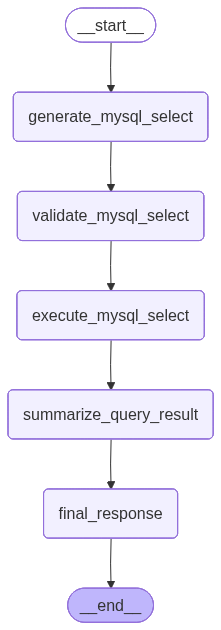

In [3]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# User input to the agent

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

config = {"configurable": {"thread_id": "1"}}
input_state = {
    "messages": [
        SystemMessage(content="You are a helpful SQL assistant for a retail database."),
        HumanMessage(content="how many users didnt make any purchase, please give the user ids as well"),
    ],
    "question": "how many users didnt make any purchase, please give the user ids as well",
    "sql": "",
    "rows": [],
    "answer": "",
    "error": "",
}
result = app.invoke(input_state, config=config)
print(result["answer"])


There are 2 users who didn’t make any purchases. Their user IDs are C-0001 and C-0025.


In [5]:
for m in result["messages"]:
    m.pretty_print()

================================ System Message ================================

You are a helpful SQL assistant for a retail database.
================================ Human Message =================================

how many users didnt make any purchase, please give the user ids as well
================================== Ai Message ==================================

There are 2 users who didn’t make any purchases. Their user IDs are C-0001 and C-0025.


# Stream to debug the internal flow of `input state`

In [6]:
from pprint import pprint

config = {"configurable": {"thread_id": "1"}}

for idx, output in enumerate(app.stream(input_state, config=config), start=1):
    print("\n" + "#" * 80)
    print(f"STREAM CHUNK {idx}")
    pprint(output)
    for key, value in output.items():
        print("=" * 50)
        print(f"📍 Node: {key}")
        print("-" * 50)
        if isinstance(value, dict) and "messages" in value:
            for msg in value["messages"]:
                print(f"{msg.type.upper()}: {msg.content}\n")
        else:
            pprint(value)
        print("=" * 50)



################################################################################
STREAM CHUNK 1
{'generate_mysql_select': {'answer': '',
                           'error': '',
                           'messages': [SystemMessage(content='You are a helpful SQL assistant for a retail database.', additional_kwargs={}, response_metadata={}, id='600ac718-f6a0-4f84-be42-c3bf9026f67a'),
                                        HumanMessage(content='how many users didnt make any purchase, please give the user ids as well', additional_kwargs={}, response_metadata={}, id='555edf61-921b-4a9f-b62e-e4d216f00608'),
                                        AIMessage(content='There are 2 users who didn’t make any purchases. Their user IDs are C-0001 and C-0025.', additional_kwargs={}, response_metadata={}, id='dfe1c7ad-1c7e-441b-b0b0-a87d52814152', tool_calls=[], invalid_tool_calls=[])],
                           'question': 'how many users didnt make any '
                                       'pu

# Follow Up Question to test the Persistent storage 

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage

config = {"configurable": {"thread_id": "1"}}
follow_up_state = {
    "messages": [
        SystemMessage(content="You are a helpful SQL assistant for a retail database."),
        HumanMessage(content="what was my previous question?"),
    ]
}
follow_up_result = app.invoke(follow_up_state, config=config)

for m in follow_up_result["messages"]:
    m.pretty_print()

================================ System Message ================================

You are a helpful SQL assistant for a retail database.
================================ Human Message =================================

how many users didnt make any purchase, please give the user ids as well
================================== Ai Message ==================================

There are 2 users who didn’t make any purchases. Their user IDs are C-0001 and C-0025.
================================== Ai Message ==================================

There are 2 users who didn’t make any purchase: C-0001 and C-0025.
================================ System Message ================================

You are a helpful SQL assistant for a retail database.
================================ Human Message =================================

what was my previous question?
================================== Ai Message ==================================

Your previous question was: "how many users didnt make any

# Stream to debug the internal flow of `follow up state`

In [8]:
from pprint import pprint

config = {"configurable": {"thread_id": "1"}}

for idx, output in enumerate(app.stream(follow_up_state, config=config), start=1):
    print("\n" + "#" * 80)
    print(f"STREAM CHUNK {idx}")
    pprint(output)
    for key, value in output.items():
        print("=" * 50)
        print(f"📍 Node: {key}")
        print("-" * 50)
        if isinstance(value, dict) and "messages" in value:
            for msg in value["messages"]:
                print(f"{msg.type.upper()}: {msg.content}\n")
        else:
            pprint(value)
        print("=" * 50)



################################################################################
STREAM CHUNK 1
{'generate_mysql_select': {'answer': 'Your previous question was: "how many '
                                     'users didnt make any purchase, please '
                                     'give the user ids as well"\n'
                                     '\n'
                                     'Result: total_users = 80 (i.e., 80 '
                                     'users).',
                           'error': '',
                           'messages': [SystemMessage(content='You are a helpful SQL assistant for a retail database.', additional_kwargs={}, response_metadata={}, id='600ac718-f6a0-4f84-be42-c3bf9026f67a'),
                                        HumanMessage(content='how many users didnt make any purchase, please give the user ids as well', additional_kwargs={}, response_metadata={}, id='555edf61-921b-4a9f-b62e-e4d216f00608'),
                                        A